# Simple Linear Regression — R

This notebook reads salary data from a CSV file, visualizes the relationship between years of experience and salary, fits a simple linear regression model, overlays the fitted line on a scatter plot, and evaluates model performance.

**Model:**

$$\text{Salary} = \beta_0 + \beta_1 \cdot \text{YearsExperience} + \varepsilon$$

In [1]:
library(ggplot2)

DATA_PATH <- "../regression_data.csv"

## Load and inspect data

In [2]:
df <- read.csv(DATA_PATH)

cat("Rows:", nrow(df), " Columns:", ncol(df), "\n")
head(df)

Rows: 10  Columns: 2 


,YearsExperience,Salary
,<dbl>,<dbl>
1,1.1,39343
2,1.3,46205
3,1.5,37731
4,2.0,43525
5,2.2,39891
6,2.9,56642


In [3]:
summary(df)

 YearsExperience     Salary     
 Min.   :1.100   Min.   :37731  
 1st Qu.:1.625   1st Qu.:40800  
 Median :2.550   Median :50325  
 Mean   :2.490   Mean   :49834  
 3rd Qu.:3.150   3rd Qu.:57052  
 Max.   :4.000   Max.   :63218  

## Scatter plot

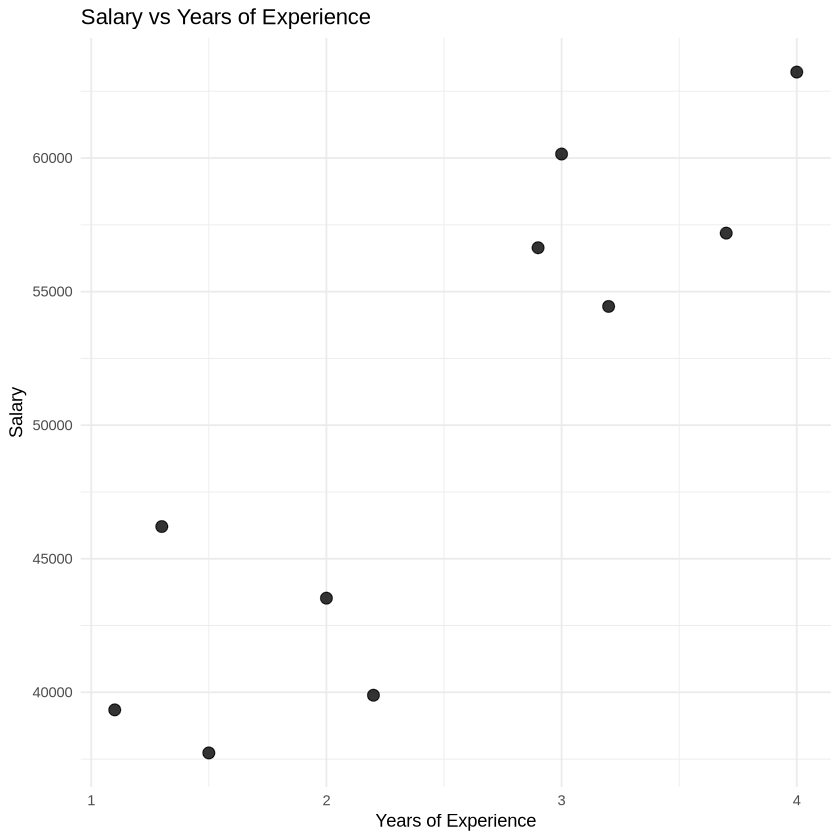

In [4]:
ggplot(df, aes(x = YearsExperience, y = Salary)) +
  geom_point(size = 3, alpha = 0.8) +
  labs(
    title = "Salary vs Years of Experience",
    x = "Years of Experience",
    y = "Salary"
  ) +
  theme_minimal()

## Fit linear model

In [5]:
model <- lm(Salary ~ YearsExperience, data = df)

cat("Intercept (beta_0):", coef(model)[1], "\n")
cat("Slope (beta_1):    ", coef(model)[2], "\n")

Intercept (beta_0): 29203.52 


Slope (beta_1):     8285.292 


## Scatter plot with regression line

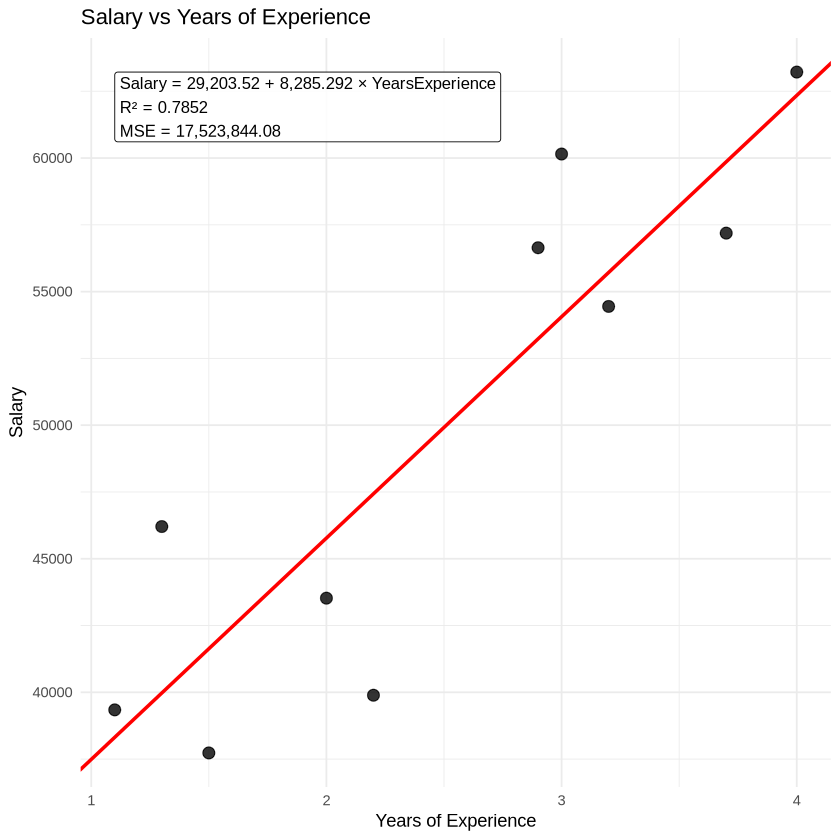

In [6]:
intercept <- coef(model)[1]
slope <- coef(model)[2]

y_pred <- predict(model)
resid <- residuals(model)

r2 <- summary(model)$r.squared
mse <- mean(resid^2)

annotation <- paste0(
  "Salary = ", format(intercept, big.mark = ",", nsmall = 2, trim = TRUE),
  " + ", format(slope, big.mark = ",", nsmall = 2, trim = TRUE),
  " \u00d7 YearsExperience\n",
  "R\u00b2 = ", format(round(r2, 4), nsmall = 4, trim = TRUE), "\n",
  "MSE = ", format(round(mse, 2), big.mark = ",", nsmall = 2, trim = TRUE)
)

ggplot(df, aes(x = YearsExperience, y = Salary)) +
  geom_point(size = 3, alpha = 0.8) +
  geom_abline(
    intercept = intercept,
    slope = slope,
    color = "red",
    linewidth = 1
  ) +
  annotate(
    "label",
    x = min(df$YearsExperience),
    y = max(df$Salary),
    label = annotation,
    hjust = 0,
    vjust = 1,
    fill = "white",
    alpha = 0.85,
    size = 3.5
  ) +
  labs(
    title = "Salary vs Years of Experience",
    x = "Years of Experience",
    y = "Salary"
  ) +
  theme_minimal()

## Evaluate model

In [7]:
summary(model)


Call:
lm(formula = Salary ~ YearsExperience, data = df)

Residuals:
    Min      1Q  Median      3Q     Max 
-7540.2 -2564.9  -199.1  2814.8  6230.6 

Coefficients:
                Estimate Std. Error t value Pr(>|t|)    
(Intercept)        29204       4092   7.136 9.84e-05 ***
YearsExperience     8285       1532   5.407 0.000641 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 4680 on 8 degrees of freedom
Multiple R-squared:  0.7852,	Adjusted R-squared:  0.7583 
F-statistic: 29.24 on 1 and 8 DF,  p-value: 0.0006407


In [8]:
y_pred <- predict(model)
resid <- residuals(model)

r2 <- summary(model)$r.squared
mse <- mean(resid^2)
rmse <- sqrt(mse)
mae <- mean(abs(resid))

cat("R-squared:", round(r2, 4), "\n")
cat("MSE:      ", round(mse, 2), "\n")
cat("RMSE:     ", round(rmse, 2), "\n")
cat("MAE:      ", round(mae, 2), "\n")

R-squared: 0.7852 


MSE:       17523844 


RMSE:      4186.15 


MAE:       3526.26 
